# Discrete State Space
## Numerical Experiments

This notebook compares our implementation of the simplex-perturbed MF-REINFORCE with the implementation of [Meunier2026] using his logits transformation, for three benchmarks:
- Two-State Two-Action Toy Problem,
- Cybersecurity,
- Distribution Planning.

Both the implemented logits-perturbed MF-REINFORCE from [Meunier2026] and the simplex-perturbed MF-REINFORCE algorithm are model-free and estimate the population flow, allowing for a fair comparison.

References:
- [Meunier2026] Meunier, M., Pham, H. and Reisinger, C., 2026. Model-free policy gradient for discrete-time mean-field control. arXiv preprint arXiv:2601.11217.
- [6] René Carmona, Mathieu Laurière, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023
- [17] Haotian Gu, Xin Guo, Xiaoli Wei, and Renyuan Xu. Dynamic programming principles for mean-field controls with learning. Operations Research, 71(4):1040–1054, 2023.
- [24] Diederik P Kingma. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.
- [25] Vassili N Kolokoltsov and Alain Bensoussan. Mean-field-game model for botnet defense in cybersecurity. Applied Mathematics & Optimization, 74(3):669–692, 2016


In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple, Union
import sys, time, logging, importlib
from pathlib import Path

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from mfc.algorithms import SimplexPerturbedMFREINFORCE, LogitsPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig
from mfc.environments import CybersecurityMFC, CybersecurityConfig, CybersecurityPolicy
from mfc.environments import DistributionPlanningMFC, DistributionPlanningConfig, DistributionPlanningPolicy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(device)


cuda


In [ ]:
# Training helper
def train_simplex_mfreinforce(
    env_cls,
    config,
    epsilon_range,
    flow_particles: int,
    policy_cls=None,
    train_horizon=None,
    validation_horizon=None,
    save_final_distribution: bool = False,
    label: str = "",
):
    results = {}
    train_horizon = train_horizon if train_horizon is not None else getattr(config, "T_train", getattr(config, "T", None))
    validation_horizon = validation_horizon if validation_horizon is not None else getattr(config, "T_val", None)
    fixed_mu0 = (
        torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
        if hasattr(config, "low") and hasattr(config, "high")
        else torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
    )
    name = label or env_cls.__name__

    for eps in epsilon_range:
        results[eps] = []

        for run_idx in range(config.training_runs):
            env = env_cls(config)
            if policy_cls is None:
                control = torch.nn.Parameter(torch.zeros(env.n_states, env.n_actions, dtype=config.dtype, device=config.device))
                optimizer = torch.optim.Adam([control], lr=config.lr)
            else:
                control = policy_cls(config)
                optimizer = torch.optim.Adam(control.parameters(), lr=config.lr)

            algorithm = SimplexPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {"episode": [], "validation_value": [], "train_return_mean": [], "grad_norm": []}
            if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                history.update({"pi_st_0": [], "pi_st_1": [], "err_pi_st_0": [], "err_pi_st_1": []})

            for episode in tqdm(range(config.n_train)):
                if hasattr(config, "low") and hasattr(config, "high"):
                    mu1 = config.low + (config.high - config.low) * torch.rand((), dtype=config.dtype, device=config.device)
                    mu0 = torch.stack([1.0 - mu1, mu1])
                else:
                    alpha = torch.ones(config.n_states, dtype=config.dtype, device=config.device)
                    mu0 = torch.distributions.Dirichlet(alpha).sample()

                control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                mu_hat_flow = algorithm.estimate_population_flow(control_view, mu0, flow_particles, horizon=train_horizon)
                D_hat = algorithm.estimate_sensitivity(control_view, mu_hat_flow, eps, config.n)
                grad_hat, diag = algorithm.gradient_estimate(control_view, mu_hat_flow, D_hat, eps, config.N, baseline="batch_mean")

                optimizer.zero_grad(set_to_none=True)
                if isinstance(control, torch.nn.Parameter):
                    control.grad = -grad_hat.detach().clone()
                else:
                    offset = 0
                    for p in control.parameters():
                        numel = p.numel()
                        p.grad = -grad_hat[offset:offset + numel].reshape_as(p).detach().clone()
                        offset += numel
                optimizer.step()

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                    with torch.no_grad():
                        if validation_horizon is None:
                            val = env.exact_value(control_view, fixed_mu0)
                        else:
                            val = env.exact_value(control_view, fixed_mu0, validation_horizon)
                    history["episode"].append(float(episode))
                    history["validation_value"].append(float(val.item()))
                    history["train_return_mean"].append(float(diag["mean_return"].item()))
                    history["grad_norm"].append(float(diag["grad_norm"].item()))

                    if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                        with torch.no_grad():
                            pi = env.policy_probs(control.detach())
                            pi_star = env.optimal_policy()
                        history["pi_st_0"].append(float(pi[0, 0].item()))
                        history["pi_st_1"].append(float(pi[1, 0].item()))
                        history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                        history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))

            control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
            with torch.no_grad():
                if validation_horizon is None:
                    final_value = env.exact_value(control_view, fixed_mu0)
                else:
                    final_value = env.exact_value(control_view, fixed_mu0, validation_horizon)

            out: Dict[str, object] = {
                "seed": run_idx,
                "final_value": float(final_value.detach().item()),
                "history": history,
                "eps_law": eps,
                "eta_aux": eps,
                "config": config,
                "flow_particles": flow_particles,
            }

            if isinstance(control, torch.nn.Parameter):
                theta = control.detach().clone()
                out["theta"] = theta
                out["final_policy"] = env.policy_probs(theta).detach().clone()
                if hasattr(env, "optimal_policy"):
                    out["optimal_policy"] = env.optimal_policy().detach().clone()
            else:
                out["policy_state"] = {k: v.detach().cpu().clone() for k, v in control.state_dict().items()}
                if save_final_distribution:
                    final_flow = env.exact_population_flow(control, fixed_mu0, train_horizon)
                    out["final_distribution"] = final_flow[-1].detach().cpu().clone()

            results[eps].append(out)

        print(f"=== {name} training completed for eps={eps} over {config.training_runs} runs ===")
        print("Final validation values:", [run["final_value"] for run in results[eps]])
        if results[eps] and "optimal_policy" in results[eps][0]:
            print("Optimal policy")
            print(results[eps][0]["optimal_policy"])
        print()

    return results


## 1. Two-State Two-Action Toy Problem [Meunier2026][17]

The action space is $\mathcal A=\{\mathrm{ST}, \mathrm{MV}\}$ and the state space is $\mathcal X = \{0, 1\}$. The transition kernel is defined as follows: for $x\in\mathcal X, a\in\mathcal A, P(x'\mid x,a)=\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'\neq x$ and $P(x'\mid x,a)=1-\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'=x$, where $\lambda_0,\lambda_1\in(0,1)$ are fixed parameters. The running reward function is defined as
\begin{align}
    r(x,a,\mu)=r(x\mu)=\mathbf 1_{x=1} - \mu(1)^2-\lambda W_1(\mu,B),
\end{align}
where $W_1$ is the 1-Wasserstein distance, $\lambda>0$ is a fixed scalar parameter and B is a Bernoulli distribution with parameter $p$ such that $1-\lambda_0\leq p\leq \lambda_1$. The terminal reward function is $g(x,\mu)=r(x,\mu)$. Although the original problem in [17] is an infinite-horizon discounted problem, we consider here a finite-horizon version with time horizon $T$. In this setting, there exists an optimal stationary policy given by
\begin{align}
    \pi^\star(a\mid 0,\mu) &= \left(1-\frac{1-p}{\lambda_0} \right)\mathbf 1_{\{a=\mathrm{ST} \}} + \frac{1-p}{\lambda_0}\mathbf 1_{\{a=\mathrm{MV}\}}, \\
    \pi^\star(a\mid 1,\mu) &= \left(1-\frac{p}{\lambda_1} \right)\mathbf 1_{\{a=\mathrm{ST}\}} +\frac{p}{\lambda_1}\mathbf 1_{\{a=\mathrm{MV}\}}.
\end{align}

We consider the same parameters as [Meunier2026]: $T=2,\lambda_0=0.5,\lambda_1=0.8,\lambda=10,p=0.6$. This policy guarantees that, no matter the initial distribution $\mu_0$, the distribution at all time steps $t\geq1$ is $\mu_t^\star=B$.

The training and evaluation are done as follows.
For each training episode we simulate the population starting from a random initial distribution $\mu=\mathcal P(\mathcal X)^\star$ by drawing $\mu(L)\sim\mathcal U([0.1,0.9])$. Every $10$ training episodes, we freeze the policy and sample a validation episode for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(\mu_0(0),\mu_0(1))=(0.2,0.8)$. During training, we compute $N=200$ main perturbed trajectories for MF-REINFORCE and also use an empirical unperturbed population flow estimated from simulated particles, with $n=10$ auxiliary trajectories for the population-flow sensitivity estimator. For this
first example, the policy considered is a simple static policy that outputs a $|\mathcal X|\times|\mathcal A|$ matrix corresponding to the probability of each action given each state. We make this particular choice of policy to check whether MF-REINFORCE is capable of recovering the optimal static policy given above.
We use the Adam optimizer [24] and train for $5,000$ episodes using a learning rate of $10^{-3}$. The experiments are run for $\varepsilon$ ranging in the set $\{0.2,0.5,1.0,2.0\}$.


FINDINGS:
One can see that a larger value of $\varepsilon$ leads to faster increase in the value function at first, but yields worse final policies. In particular, we see that choosing ε too large can lead to catastophic failure. To evaluate how well the learned policies match the optimal static policy $\pi^\star$, we compute the average absolute errors in the resulting estimates of $\pi(\mathrm{ST}\mid 0)$ and $\pi(\mathrm{ST}\mid 1)$ over $5$ independent training runs for each value of $\varepsilon$ considered. The results are reported in Table 1. These results match adequately with the curves of Figure 1: the smaller $\varepsilon$, the better and closer to optimal the learned policy is.


In [ ]:
# Configuration and parameters
config = TwoStateConfig(device=device, dtype=torch.float64)

flow_particles = 200 # Particles for the empirical unperturbed population flow
epsilon_range = [0.05, 0.1, 0.2, 0.5] # Range of epsilon values to test


In [ ]:
# Training
results_twostate = train_simplex_mfreinforce(TwoStateMFC, config, epsilon_range, flow_particles, label="Two-state")


### Gradient sanity check

For a fixed policy parameter, we estimate $\widehat G_{\lambda,\eta,B,n}(\theta)$ with large batches using the empirical flow used by the algorithm, then compare its direction with an autograd oracle computed through the exact population flow. The primary diagnostic is cosine similarity against $\nabla_\theta J^\lambda(\theta)$; the unperturbed $\nabla_\theta J(\theta)$ is shown as a nearby reference.


In [4]:
# Gradient sanity check
sanity_eps = epsilon_range[0]
theta_check = results_twostate[sanity_eps][0]["theta"]
eps_law, eta_aux = sanity_eps, sanity_eps
n_aux: int = 1_000 # Consider bigger values for the check 
B: int = 2_000
flow_particles: int = 5_000
n_q_oracle: int = 20_000

env = TwoStateMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)

mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
theta0 = theta_check.detach().clone().to(dtype=config.dtype, device=config.device)

with torch.no_grad():
    mu_hat_flow = algorithm.estimate_population_flow(theta0, mu0, flow_particles)
    exact_flow = env.exact_population_flow(theta0, mu0)
    D_hat = algorithm.estimate_sensitivity(theta0, mu_hat_flow, eta_aux, n_aux)
    grad_hat, diag = algorithm.gradient_estimate(theta0, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

theta_var = theta0.detach().clone().requires_grad_(True)

# Exact perturbed value mc
mu_flow = env.exact_population_flow(theta_var, mu0)
value = torch.zeros((), dtype=theta_var.dtype, device=theta_var.device)

for t in range(env.config.T + 1):
    q_t = algorithm.sample_q_batch(n_q_oracle)
    M_t = (1.0 - eps_law) * mu_flow[t].unsqueeze(0) + eps_law * q_t
    mu1 = M_t[:, 1]
    population_penalty = (-mu1.square() - env.config.lam * torch.abs(mu1 - env.target_B[1])).mean()
    state_reward = mu_flow[t, 1]
    value = value + state_reward + population_penalty

# Exact perturbed gradient mc
(grad,) = torch.autograd.grad(value, theta_var)
J_lam, grad_J_lam = value.detach(), grad.detach()

# Exact unperturbed gradient
value = env.exact_value(theta_var, mu0)
(grad,) = torch.autograd.grad(value, theta_var)
J, grad_J = value.detach(), grad.detach()

def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())

print("Cosine vs grad J_lambda:", cosine_similarity_flat(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cosine_similarity_flat(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


Cosine vs grad J_lambda: -0.9880104043291601
Cosine vs grad J: -0.9880006098044924
Norm G_hat: 3.3383780875331444
Norm grad J_lambda: 4.539568330201786
Norm grad J: 4.754547170998486
J_lambda oracle MC: -3.516195777110431
J oracle: -3.706396805794456
Empirical flow L1 error: 0.06414746615642497
Mean Return: -3.705257444802956
Std. Return: 1.0000250094558438


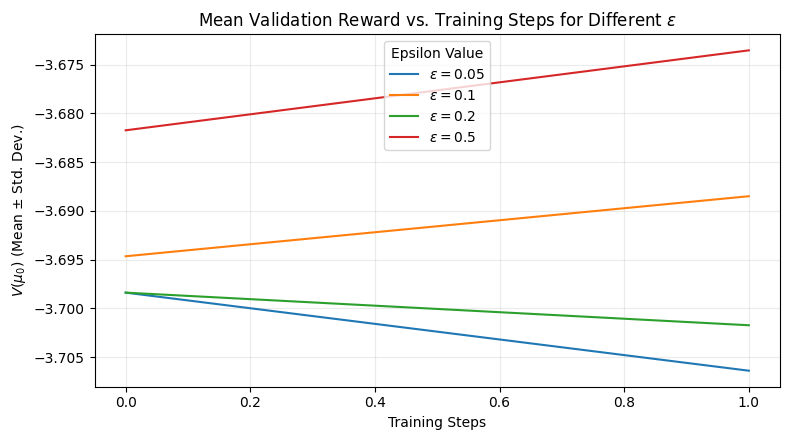

,avg_abs_err_pi(ST|0),std_abs_err_pi(ST|0),avg_abs_err_pi(ST|1),std_abs_err_pi(ST|1),avg_abs_err_policy
epsilon,,,,,
0.05,0.3010,0.0,0.2490,0.0,0.2750
0.10,0.2991,0.0,0.2499,0.0,0.2745
0.20,0.3008,0.0,0.2493,0.0,0.2751
0.50,0.2990,0.0,0.2510,0.0,0.2750


In [ ]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
table_rows = []
std_ddof = 1 if config.training_runs > 1 else 0

for eps in epsilon_range:
    runs = results_twostate[eps]

    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float,)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=std_ddof)

    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

    pi_star = runs[0]["optimal_policy"].detach().cpu().numpy()
    final_policies = np.asarray(
        [run["final_policy"].detach().cpu().numpy() for run in runs],
        dtype=float,
    )
    st_errors = np.abs(final_policies[:, :, 0] - pi_star[:, 0])

    table_rows.append(
        {
            "epsilon": eps,
            "avg_abs_err_pi(ST|0)": st_errors[:, 0].mean(),
            "std_abs_err_pi(ST|0)": st_errors[:, 0].std(ddof=std_ddof),
            "avg_abs_err_pi(ST|1)": st_errors[:, 1].mean(),
            "std_abs_err_pi(ST|1)": st_errors[:, 1].std(ddof=std_ddof),
            "avg_abs_err_policy": st_errors.mean(axis=1).mean(),
        }
    )

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_1 = pd.DataFrame(table_rows).set_index("epsilon")
display(table_1.round(4))


## 2. Cybersecurity Example [Meunier2026][25][6]

We consider a large population of computers.

Four states:
- DI: defended and infected
- DS: defended and susceptible
- UI: undefended and infected
- US: undefended and susceptible

Action space is $\mathcal A = \{0,1\}$, where $0$ means keeping the same level of protection $\mathrm D$ or $\mathrm U$, and $1$ means updating the level of protection (from $\mathrm D$ to $\mathrm U$ or vice versa).

When infected, the computer recovers at rate $q_\mathrm{rec}^D$ or $q_\mathrm{rec}^U$ depending on the level of protection. When susceptible, the computer might
be infected either directly by a hacker or by the other infected computers, at rates depending on the level of protection of the susceptible computer and the other infected computers.

Originally the problem was formulated in continuous time, and the infinitesimal generator matrix can be written, given the current distribution of the population $\mu$ and action chosen by the computer $a$, as
\begin{align}
    Q^{\mu, a} =
    \begin{pmatrix}
        \dots & q_{\mathrm{rec}}^D & \lambda a & 0 \\
        Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} & \dots & 0 & \lambda a \\
        \lambda a & 0 & \dots & q_\mathrm{rec}^U \\
        0 & \lambda a & Q_{\mathrm{US} \rightarrow \mathrm{UI}} & \dots  
    \end{pmatrix},
\end{align}
where
\begin{align}
    Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} &= v_H q_\mathrm{inf}^D + \beta_{\mathrm{DD}}\mu(\mathrm{DI}) + \beta_{\mathrm{UD}}\mu(UI), \\
    Q_{\mathrm{US} \rightarrow \mathrm{UI}}^{\mu, a} &= v_H q_\mathrm{inf}^U + \beta_\mathrm{UU}\mu(\mathrm{UI}) + \beta_\mathrm{DU}\mu(\mathrm{DI}),
\end{align}
and all instances of $\dots$ should be replaced by values to make each row sum to $0$.

Each computer incurs a cost whenever it is defended or infected. The individual cost per unit of time is given by $f(x) = k_D\mathbf 1_{x\in\{\mathrm{DI}, \mathrm{DS}\}} + k_I\mathbf 1_{x\in\{\mathrm{DI},\mathrm{UI} \}}.

The model is adapted to a discrete time setting by considering a time grid $0, \Delta t, 2\Delta t, \ldots, N_{\mathrm{epi}}\Delta t$. Between two points of the time grid, the transition matrix is given by $P_{\Delta t}^{\mu, a} = \exp(\Delta t Q^{\mu, a})$, and the running reward is $r_{\Delta t}(x, a, \mu) = r_{\Delta t}(x) = -\Delta t f(x)$.

For the numerical experiments, we use the same values for the parameters as in [Meunier2026]. The rewards are discounted by $\gamma =0.5$ and the terminal reward is taken to be the same as the running reward.

The training and evaluation are done as follows. As the transition probability is stationary and the terminal reward is the same as the step reward, the length of a training episode is taken to be $T_\mathrm{train}=3$ to mitigate the "curse of time" (cf. [Meunier2026] - Remark 3.2), and for each training episode we simulate the population starting from a random initial distribution $\mu\in \mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode of length $T_\mathrm{val}=50$, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(1/4, 1/4, 1/4, 1/4).
During training, the implementation below uses the same simplex-perturbed empirical-flow framework as in Problem 1. We compute $N=200$ main perturbed trajectories, estimate the unperturbed population flow from simulated particles, and use $n$ auxiliary trajectories for the population-flow sensitivity estimator. The policy is given by a 2-layer MLP, with 32 hidden units and tanh activations; it takes as input $t, \mu$ and outputs a $|\mathcal X|\times |\mathcal A|$ matrix corresponding to the probability of each action given each state.
We use the Adam optimizer with learning rate $10^{-3}$.
The experiments below use simplex perturbations $\varepsilon \in (0,1)$.

FINDINGS: We clearly see the effect of $\varepsilon$ on the variance of the overall training algorithm: the smaller the perturbation, the more erratic the gradient estimation becomes, which leads to slower convergence. Surprisingly, taking a smaller
value of epsilon does not lead to a better policy. To confirm that the policy obtained is not suboptimal, we compare the state distribution evolution under the learned policy to the results obtained in [6] with mean-field Q-learning. The resulting flow of distributions is shown in Figure 3. Clearly, we see that the qualitative behaviour of the population under the policy learned using
MF-REINFORCE eventually matches the one learned using mean-field Q-learning in [6].


In [16]:
# Configuration and parameters
config = CybersecurityConfig(device=device, dtype=torch.float64)

flow_particles = 200
epsilon_range = [0.2, 0.5, 0.8]


In [ ]:
# Training
results_cybersecurity = train_simplex_mfreinforce(CybersecurityMFC, config, epsilon_range, flow_particles, policy_cls=CybersecurityPolicy, label="Cybersecurity")


In [8]:
# Sanity Check
sanity_eps = epsilon_range[0]
policy = CybersecurityPolicy(config)
policy.load_state_dict(results_cybersecurity[sanity_eps][0]["policy_state"])
eps_law, eta_aux = sanity_eps, sanity_eps
B: int = 512
n_aux: int = 64
flow_particles: int = 1_000
n_q_oracle: int = 512


env = CybersecurityMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train).detach()
D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

# Compute the exact perturbed value with MC
algorithm = SimplexPerturbedMFREINFORCE(env)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train)
q_paths = algorithm.sample_q_batch(n_q_oracle * (config.T_train + 1)).reshape(n_q_oracle, config.T_train + 1, env.n_states)
value = torch.zeros((), dtype=env.config.dtype, device=env.config.device)

for r in range(n_q_oracle):
    state_law = mu0
    for t in range(config.T_train):
        M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
        value = value + (env.config.gamma ** t) * (state_law * env.reward_by_state).sum()
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = (1.0 - eps_law) * exact_flow[config.T_train] + eps_law * q_paths[r, config.T_train]
    value = value + (env.config.gamma ** config.T_train) * (state_law * env.reward_by_state).sum()

value = value / n_q_oracle

# Compute the exact perturbed gradient with MC
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam, grad_J_lam = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Compute the exact unperturbed gradient
value = env.exact_value(policy, mu0, config.T_train)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J, grad_J = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Helper cosine function
def cyber_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", cyber_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cyber_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


Cosine vs grad J_lambda: 0.18778590813595283
Cosine vs grad J: 0.1879302120267138
Norm G_hat: 8.718126178553508
Norm grad J_lambda: 0.0032263223805830744
Norm grad J: 0.003225223530690136
J_lambda oracle MC: -0.1487885493823474
J oracle: -0.14877234019487595
Empirical flow L1 error: 0.31125139491690046
Mean Return: -0.14578125000000003
Std. Return: 0.1024930923739498


### Results


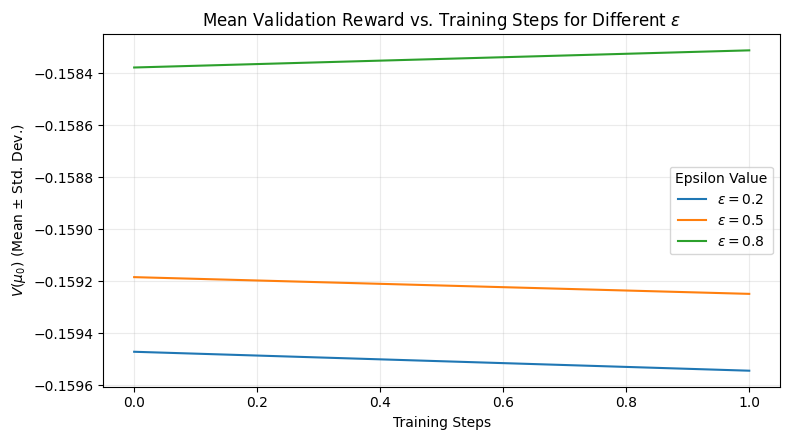

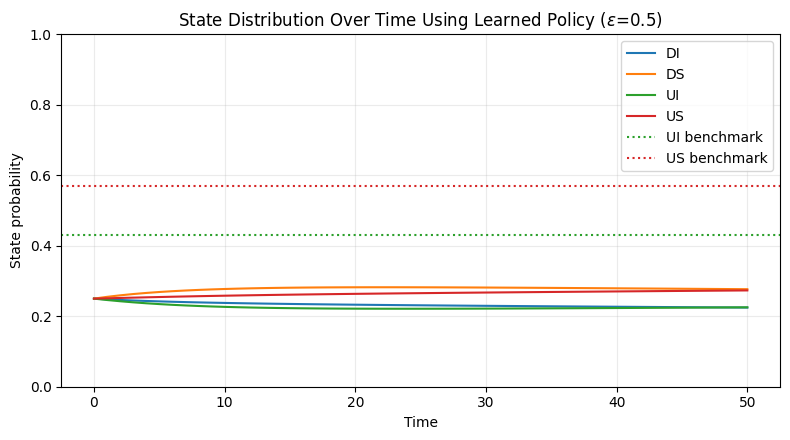

In [ ]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
cyber_std_ddof = 1 if config.training_runs > 1 else 0

for eps in epsilon_range:
    runs = results_cybersecurity[eps]
    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=cyber_std_ddof)
    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

flow_eps = 0.5 if 0.5 in results_cybersecurity else epsilon_range[0]
policy = CybersecurityPolicy(config)
policy.load_state_dict(results_cybersecurity[flow_eps][0]["policy_state"])

with torch.no_grad():
        flow = env.exact_population_flow(
            policy, torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device), config.T_val
        ).cpu().numpy()

# Benchmark values from Carmona, Laurière, Tan 2021
mfq_final_benchmark = {
    "UI": 0.43,
    "US": 0.57,
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for state_idx, state_name in enumerate(config.cyber_state_names):
    ax.plot(np.arange(config.T_val + 1), flow[:, state_idx], label=state_name)

ax.axhline(mfq_final_benchmark["UI"], linestyle=":", color="tab:green", label="UI benchmark")
ax.axhline(mfq_final_benchmark["US"], linestyle=":", color="tab:red", label="US benchmark")

ax.set_title(f"State Distribution Over Time Using Learned Policy ($\\epsilon$={flow_eps})")
ax.set_xlabel("Time")
ax.set_ylabel("State probability")
ax.set_ylim(0.0, 1.0)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 3. Distribution Planning Example [Meunier2026][6]

Consider a problem similar to the distribution planning example of [6] (Section 6.2). The goal is to match a fixed target distribution $\mu_\mathrm{target}\in\mathcal P(\mathcal X)$, where $\mathcal X=\mathbb Z/10\mathbb Z$. The action space is $\mathcal A=\{-1,0,+1\}$, and the transition probability is deterministic $P(\cdot\mid x,a,\mu)=\delta_{x+a}$. At each step, we penalize the deviation of the population from the target distribution and penalize movement: $r(x,a,\mu)=-\lambda |a|-\sum_{y\in\mathcal X}|\mu(y)-\mu_\mathrm{target}(y)|^2$. The terminal reward is $g(x,\mu)=-\sum_{y\in\mathcal X}|\mu(y)-\mu_\mathrm{target}(y)|^2$.

We use $T=5$, $\lambda=0.01$, $N=500$, $n=10$, an MLP policy with two hidden layers of width 256 and tanh activations, Adam with learning rate $10^{-4}$, and $\varepsilon\in\{0.5,0.75,1.0,2.0\}$. Validation starts from $\mu_0=\mathcal U(\mathcal X)$.


In [ ]:
# Configuration and parameters
config = DistributionPlanningConfig(device=device, dtype=torch.float64)

flow_particles = 500
epsilon_range = [0.1, 0.5, 0.75]


In [ ]:
# Training
results_distribution_planning = train_simplex_mfreinforce(DistributionPlanningMFC, config, epsilon_range, flow_particles, policy_cls=DistributionPlanningPolicy, save_final_distribution=True, label="Distribution planning")


In [12]:
# Sanity check
sanity_eps = 1.0 if 1.0 in results_distribution_planning else epsilon_range[0]
eps_law, eta_aux = sanity_eps, sanity_eps
B = 512
n_aux_check = 64
flow_particles_check = 1_000
n_q_oracle = 512

env = DistributionPlanningMFC(config)
policy = DistributionPlanningPolicy(config)
policy.load_state_dict(results_distribution_planning[sanity_eps][0]["policy_state"])
algorithm = SimplexPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles_check, horizon=config.T)
exact_flow_detached = env.exact_population_flow(policy, mu0, config.T).detach()
D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux_check)
grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

exact_flow = env.exact_population_flow(policy, mu0, config.T)
q_paths = algorithm.sample_q_batch(n_q_oracle * (config.T + 1)).reshape(n_q_oracle, config.T + 1, env.n_states)
value = torch.zeros((), dtype=config.dtype, device=config.device)

for r in range(n_q_oracle):
    state_law = mu0
    for t in range(config.T):
        M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
        pi = policy.probs(t, M_t)
        step_reward = torch.zeros((), dtype=config.dtype, device=config.device)
        for x in range(config.n_states):
            for a in range(config.n_actions):
                step_reward = step_reward + state_law[x] * pi[x, a] * env.reward(x, M_t, a)
        value = value + step_reward
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = (1.0 - eps_law) * exact_flow[config.T] + eps_law * q_paths[r, config.T]
    value = value + env.terminal_reward(0, M_T)
value = value / n_q_oracle

grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam = value.detach()
grad_J_lam = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

value = env.exact_value(policy, mu0, config.T)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J = value.detach()
grad_J = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

def distribution_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", distribution_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", distribution_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow_detached).sum().item()))


Cosine vs grad J_lambda: 0.13552418428817337
Cosine vs grad J: 0.1608335346061153
Norm G_hat: 0.042055972341236585
Norm grad J_lambda: 0.01290028369967144
Norm grad J: 0.4255083012078955
J_lambda oracle MC: -0.8040121387659136
J oracle: -0.2899347016108924
Empirical flow L1 error: 0.5803846720824245


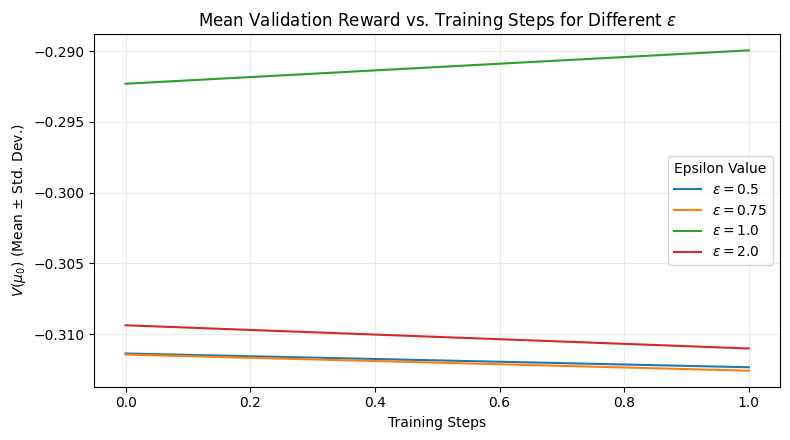

,final_value_mean,final_value_std,final_l2_to_target
epsilon,,,
0.50,-0.3123,0.0,0.2196
0.75,-0.3126,0.0,0.2186
1.00,-0.2899,0.0,0.2042
2.00,-0.3110,0.0,0.2200


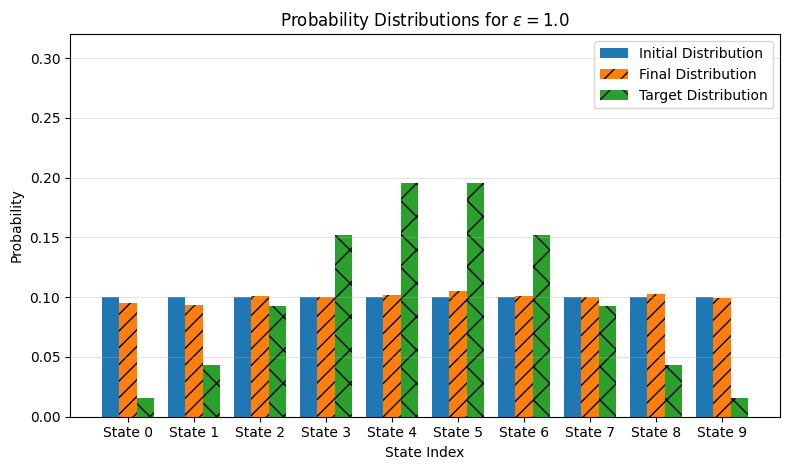

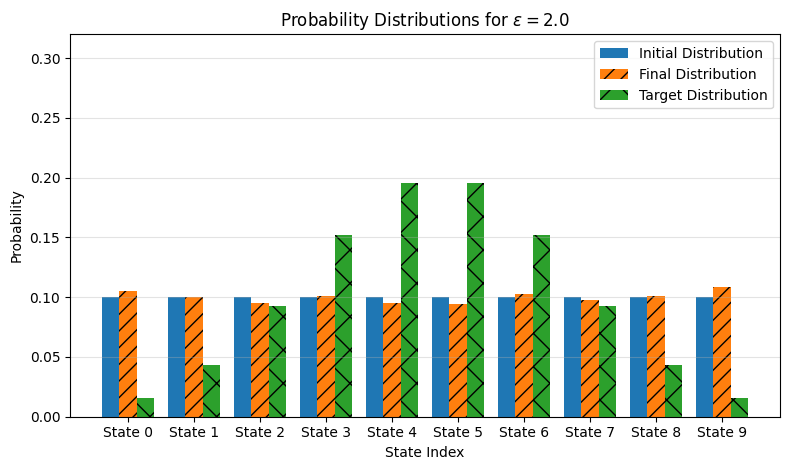

In [ ]:
# Results
fig, ax = plt.subplots(figsize=(8, 4.5))
distribution_std_ddof = 1 if config.training_runs > 1 else 0
table_rows = []

env = DistributionPlanningMFC(config)
fixed_mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

for eps in epsilon_range:
    runs = results_distribution_planning[eps]
    episodes = np.asarray(runs[0]["history"]["episode"], dtype=float)
    validation_rewards = np.asarray([run["history"]["validation_value"] for run in runs], dtype=float)
    reward_mean = validation_rewards.mean(axis=0)
    reward_std = validation_rewards.std(axis=0, ddof=distribution_std_ddof)

    ax.plot(episodes, reward_mean, label=rf"$\varepsilon={eps}$")
    ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.18)

    final_distributions = np.asarray([run["final_distribution"].numpy() for run in runs], dtype=float)
    target = env.target.detach().cpu().numpy()
    table_rows.append({
        "epsilon": eps,
        "final_value_mean": validation_rewards[:, -1].mean(),
        "final_value_std": validation_rewards[:, -1].std(ddof=distribution_std_ddof),
        "final_l2_to_target": np.linalg.norm(final_distributions - target, axis=1).mean(),
    })

ax.set_title("Mean Validation Reward vs. Training Steps for Different $\\epsilon$")
ax.set_xlabel("Training Steps")
ax.set_ylabel("$V(\\mu_0)$ (Mean $\\pm$ Std. Dev.)")
ax.legend(title="Epsilon Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_distribution = pd.DataFrame(table_rows).set_index("epsilon")
display(table_distribution.round(4))

figure_eps = [eps for eps in [1.0, 2.0] if eps in results_distribution_planning]
states = np.arange(config.n_states)
initial = np.full(config.n_states, 1.0 / config.n_states)
target = DistributionPlanningMFC(config).target.detach().cpu().numpy()

for eps in figure_eps:
    env = DistributionPlanningMFC(config)
    policy = DistributionPlanningPolicy(config)
    policy.load_state_dict(results_distribution_planning[eps][0]["policy_state"])

    with torch.no_grad():
        flow = env.exact_population_flow(policy, fixed_mu0, config.T).detach().cpu().numpy()
    final = flow[-1]

    fig, ax = plt.subplots(figsize=(8, 4.8))
    width = 0.26
    ax.bar(states - width, initial, width, label="Initial Distribution")
    ax.bar(states, final, width, label="Final Distribution", hatch="//")
    ax.bar(states + width, target, width, label="Target Distribution", hatch="x")
    ax.set_title(rf"Probability Distributions for $\varepsilon={eps}$")
    ax.set_xlabel("State Index")
    ax.set_ylabel("Probability")
    ax.set_xticks(states)
    ax.set_xticklabels([f"State {i}" for i in states])
    ax.set_ylim(0.0, max(0.32, 1.1 * max(initial.max(), final.max(), target.max())))
    ax.legend()
    ax.grid(axis="y", alpha=0.35)
    fig.tight_layout()
    plt.show()
